## Human in the Loop

In [1]:
import os
from langchain.chat_models import init_chat_model
llm=init_chat_model("ollama:llama3.1:8b")
llm

d:\ai-engineer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatOllama(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, model='llama3.1:8b')

In [2]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

In [3]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [18]:
builder = StateGraph(State)

In [19]:
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]


In [20]:
searchTool = TavilySearch(max_results=2)

tools = [searchTool,human_assistance]
llm_with_tool=llm.bind_tools(tools=tools)

In [21]:
def chatbot(state:State):
    message=llm_with_tool.invoke(state['messages'])
    return {"messages":[message]}

In [22]:
builder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools=tools)
builder.add_node("tools",tool_node)

builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

builder.add_edge("chatbot","tools")
builder.add_edge("tools","chatbot")
builder.add_edge(START,"chatbot")



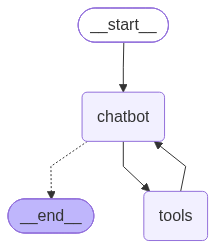

In [24]:
memory=MemorySaver()

graph=builder.compile(checkpointer=memory)

from IPython.display import Image,display


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [25]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (be68f71f-f34b-4e4f-9174-4a7f0208ef3d)
 Call ID: be68f71f-f34b-4e4f-9174-4a7f0208ef3d
  Args:
    query: I need some expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (be68f71f-f34b-4e4f-9174-4a7f0208ef3d)
 Call ID: be68f71f-f34b-4e4f-9174-4a7f0208ef3d
  Args:
    query: I need some expert guidance and assistance for building an AI agent.


In [26]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (be68f71f-f34b-4e4f-9174-4a7f0208ef3d)
 Call ID: be68f71f-f34b-4e4f-9174-4a7f0208ef3d
  Args:
    query: I need some expert guidance and assistance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Based on the tool call response, I can provide a recommendation for building an AI agent.

It is recommended to use LangGraph as it is more reliable and extensible than simple autonomous agents. This should help you with your requirements of building an AI agent. Is there anything else you need assistance with?
================================== Ai Message ====

KeyboardInterrupt: 